**Подключение библиотек и скриптов**

In [1]:
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [2]:
warnings.filterwarnings("ignore")
matplotlib.rcParams.update({"font.size": 14})
sns.set_style("whitegrid")

random_state = 42
np.random.seed(random_state)

In [3]:
def evaluate_preds(true_values, pred_values, save=False):
    """Оценивает качество предсказаний на исходной шкале цены."""
    r2_value = r2_score(true_values, pred_values)
    rmse_value = np.sqrt(mean_squared_error(true_values, pred_values))
    mse_value = mean_squared_error(true_values, pred_values)

    print(f"R2: {r2_value:.4f}")
    print(f"RMSE: {rmse_value:.2f}")
    print(f"MSE: {mse_value:.2f}")

    plt.figure(figsize=(8, 8))
    plt.scatter(pred_values, true_values, s=20, alpha=0.5)
    min_value = min(true_values.min(), pred_values.min())
    max_value = max(true_values.max(), pred_values.max())
    plt.plot([min_value, max_value], [min_value, max_value], "r--", lw=2)
    plt.xlabel("Predicted values")
    plt.ylabel("True values")
    plt.title("Предсказанные значения vs Истинные значения")
    plt.tight_layout()
    plt.show()

**Пути к директориям и файлам**

In [9]:
DATASET_PATH_TRAIN = "train.csv"
DATASET_PATH_TEST = "test.csv"
DATASET_PATH_SAMPLE_SUBMIT = "sample_submission.csv" 

**Загрузка данных**

Описание датасета

- **Id** — идентификатор объекта
- **SalePrice** — целевая переменная, цена продажи дома
- Признаки описывают площадь, качество строительства, год постройки, подвал, гараж, район и другие характеристики дома
- **train.csv** содержит признаки и целевую переменную
- **test.csv** содержит только признаки
- **sample_submission.csv** нужен для формирования итогового файла submission

In [10]:
df_train = pd.read_csv(DATASET_PATH_TRAIN, sep=",")
df_test = pd.read_csv(DATASET_PATH_TEST, sep=",")
sample_submission = pd.read_csv(DATASET_PATH_SAMPLE_SUBMIT, sep=",")

df_train.tail(7)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1453,1454,20,RL,90.0,17217,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2006,WD,Abnorml,84500
1454,1455,20,FV,62.0,7500,Pave,Pave,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,10,2009,WD,Normal,185000
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [11]:
f"Всего строк: {df_train.shape[0]}, Всего столбцов: {df_train.shape[1]}" 

'Всего строк: 1460, Всего столбцов: 81'

In [12]:
df_test.tail(7)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
1452,2913,160,RM,21.0,1533,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,12,2006,WD,Abnorml
1453,2914,160,RM,21.0,1526,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,GdPrv,NaN,0,6,2006,WD,Normal
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal
1458,2919,60,RL,74.0,9627,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,11,2006,WD,Normal


In [13]:
f"Всего строк: {df_test.shape[0]}, Всего столбцов: {df_test.shape[1]}" 

'Всего строк: 1459, Всего столбцов: 80'

# Обзор переменных

In [14]:
df_train.dtypes.head(20)

Id                int64
MSSubClass        int64
MSZoning            str
LotFrontage     float64
LotArea           int64
Street              str
Alley               str
LotShape            str
LandContour         str
Utilities           str
LotConfig           str
LandSlope           str
Neighborhood        str
Condition1          str
Condition2          str
BldgType            str
HouseStyle          str
OverallQual       int64
OverallCond       int64
YearBuilt         int64
dtype: object

Обзор количественных переменных

In [15]:
df_num_features = df_train.select_dtypes(include=["float64", "int64"])
df_num_features.describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [16]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

Обзор номинативных переменных

In [17]:
df_obj_features = df_train.select_dtypes(include="object")
df_obj_features.head()

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1,RL,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
2,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
3,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,Detchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Abnorml
4,RL,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal


In [18]:
df_obj_features.nunique().sort_values(ascending=False).head(20)

Neighborhood     25
Exterior2nd      16
Exterior1st      15
Condition1        9
SaleType          9
HouseStyle        8
RoofMatl          8
Condition2        8
Functional        7
BsmtFinType2      6
RoofStyle         6
BsmtFinType1      6
SaleCondition     6
Heating           6
Foundation        6
GarageType        6
ExterCond         5
LotConfig         5
MSZoning          5
GarageCond        5
dtype: int64

# EDA

Делаем EDA для:

1. Анализа целевой переменной
2. Анализа пропусков
3. Идей для генерации новых фич

## 1. Распределение целевой переменной

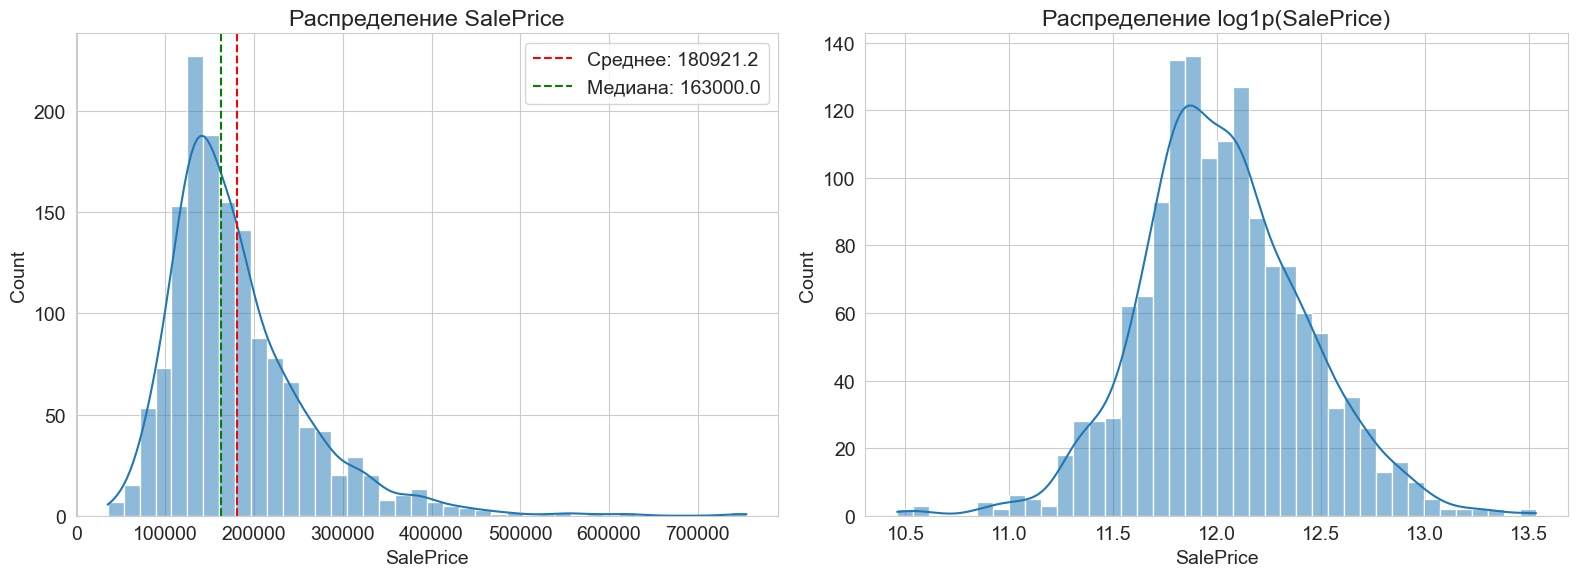

In [19]:
target_mean = round(df_train["SalePrice"].mean(), 2)
target_median = round(df_train["SalePrice"].median(), 2)

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.histplot(df_train["SalePrice"], bins=40, kde=True)
plt.axvline(target_mean, color="red", linestyle="--", label=f"Среднее: {target_mean}")
plt.axvline(target_median, color="green", linestyle="--", label=f"Медиана: {target_median}")
plt.title("Распределение SalePrice")
plt.legend()

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df_train["SalePrice"]), bins=40, kde=True)
plt.title("Распределение log1p(SalePrice)")

plt.tight_layout()
plt.show()

## 2. Анализ пропусков

In [20]:
nan_df = (
    df_train.isna()
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
nan_df.columns = ["feature", "nan_count"]
nan_df["nan_share"] = nan_df["nan_count"] / df_train.shape[0]
nan_df.head(20)

,feature,nan_count,nan_share
0,PoolQC,1453,0.995205
1,MiscFeature,1406,0.963014
2,Alley,1369,0.937671
3,Fence,1179,0.807534
4,MasVnrType,872,0.597260
5,FireplaceQu,690,0.472603
6,LotFrontage,259,0.177397
7,GarageQual,81,0.055479
8,GarageFinish,81,0.055479
9,GarageType,81,0.055479


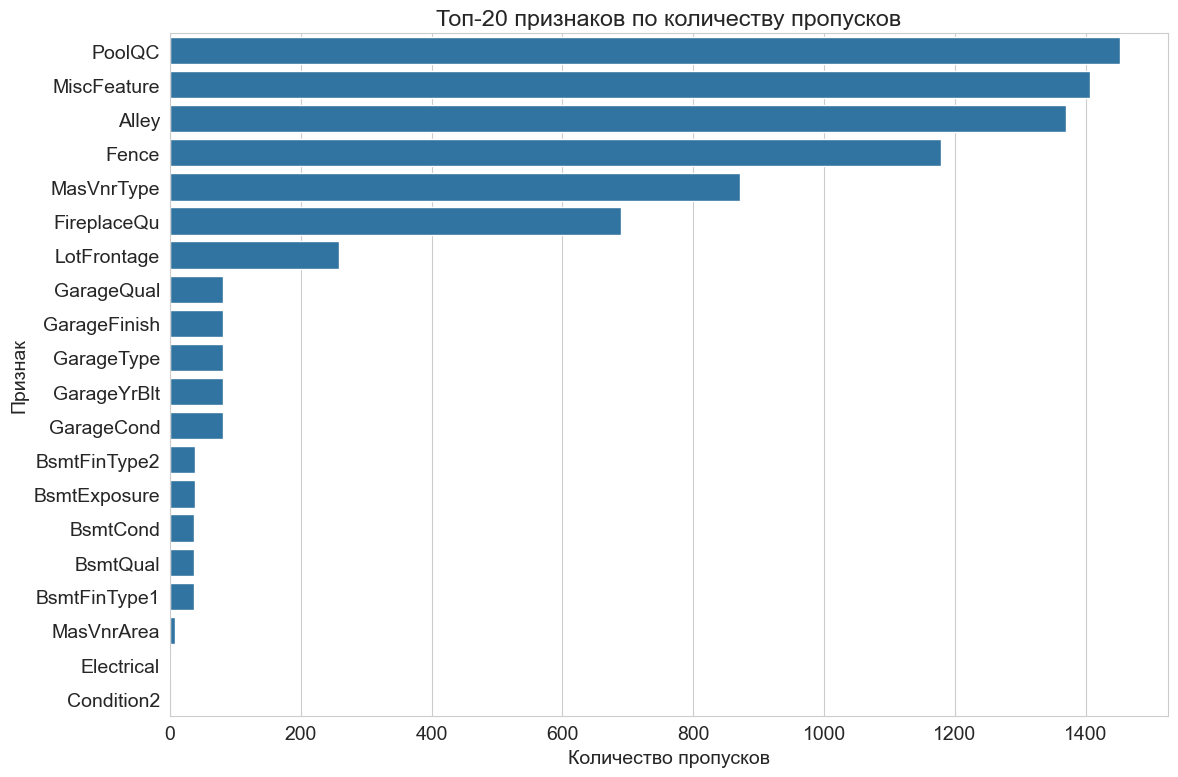

In [21]:
plt.figure(figsize=(12, 8))
sns.barplot(
    data=nan_df.head(20),
    y="feature",
    x="nan_count",
)
plt.title("Топ-20 признаков по количеству пропусков")
plt.xlabel("Количество пропусков")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()

## 3. Анализ связи числовых признаков с целевой переменной

In [22]:
corr_with_target = (
    df_num_features.corr(numeric_only=True)["SalePrice"]
    .drop("SalePrice")
    .sort_values(key=np.abs, ascending=False)
)

corr_with_target.head(15)

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
Name: SalePrice, dtype: float64

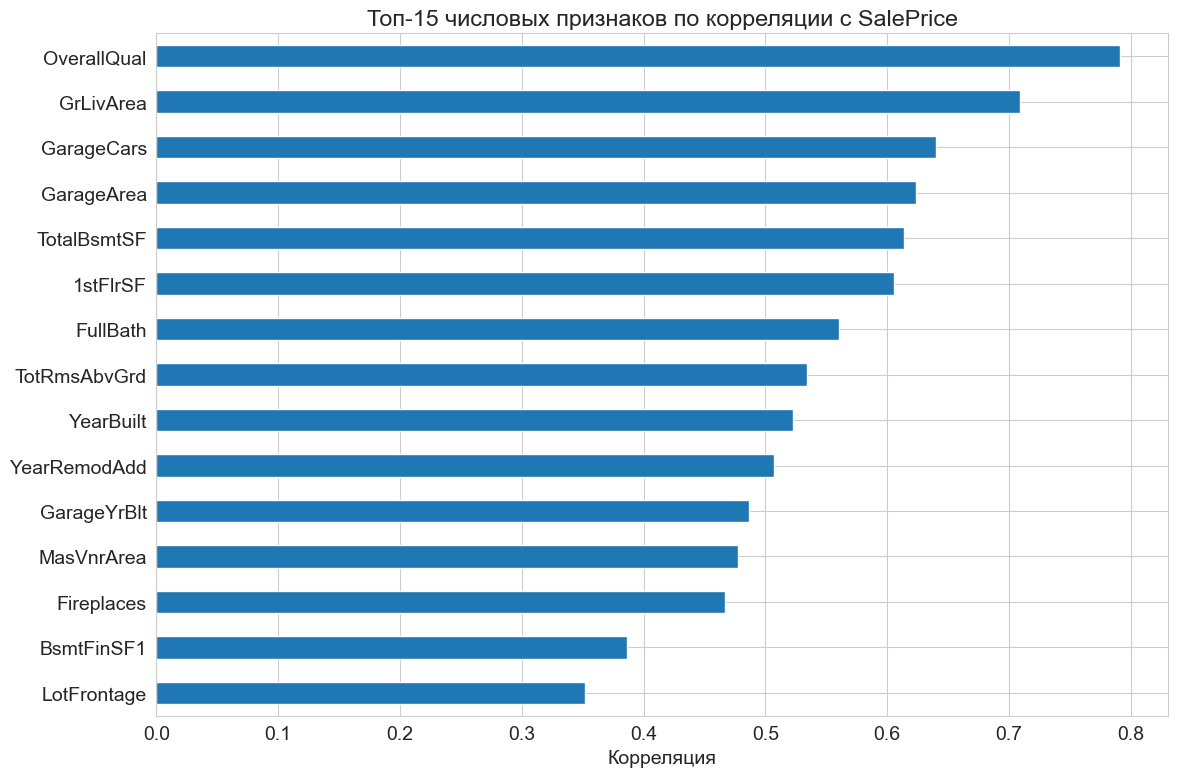

In [23]:
plt.figure(figsize=(12, 8))
corr_with_target.head(15).sort_values().plot(kind="barh")
plt.title("Топ-15 числовых признаков по корреляции с SalePrice")
plt.xlabel("Корреляция")
plt.tight_layout()
plt.show()

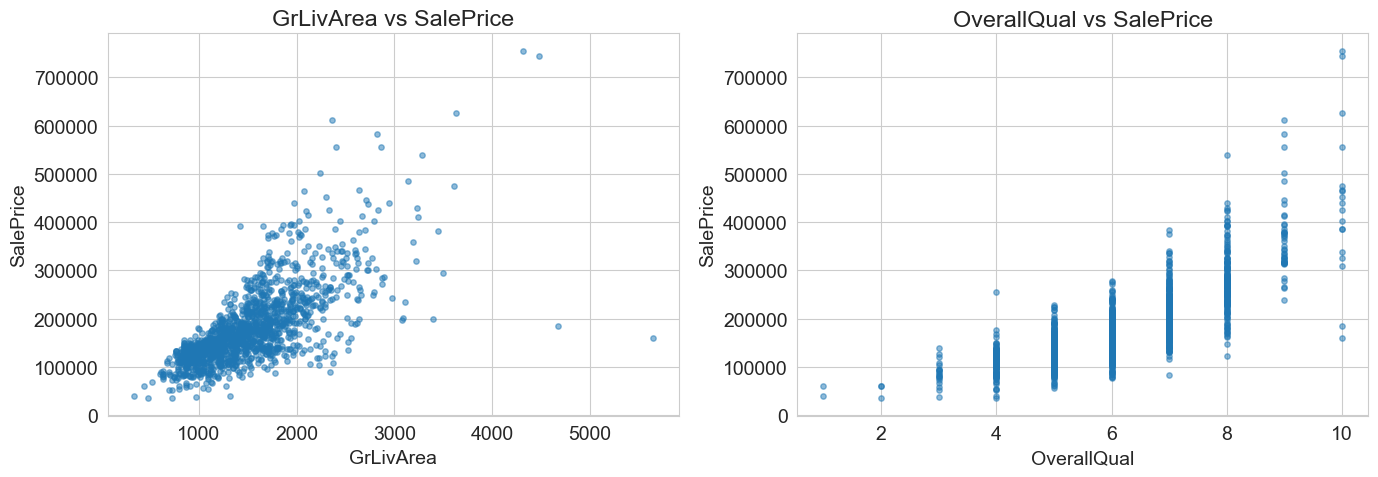

In [24]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(df_train["GrLivArea"], df_train["SalePrice"], s=15, alpha=0.5)
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("GrLivArea vs SalePrice")

plt.subplot(1, 2, 2)
plt.scatter(df_train["OverallQual"], df_train["SalePrice"], s=15, alpha=0.5)
plt.xlabel("OverallQual")
plt.ylabel("SalePrice")
plt.title("OverallQual vs SalePrice")

plt.tight_layout()
plt.show()

# 4. Предобработка данных и Feature engineering

In [25]:
class DataPreprocessing(BaseEstimator, TransformerMixin):
    """Базовая предобработка данных для House Prices."""

    def __init__(self):
        self.columns_to_drop = [
            "Id",
            "PoolQC",
            "MiscFeature",
            "Alley",
            "Fence",
        ]
        self.none_fill_columns = [
            "BsmtQual",
            "BsmtCond",
            "BsmtExposure",
            "BsmtFinType1",
            "BsmtFinType2",
            "FireplaceQu",
            "GarageType",
            "GarageFinish",
            "GarageQual",
            "GarageCond",
            "MasVnrType",
        ]

    def fit(self, x, y=None):
        return self

    def transform(self, x):
        x = x.copy()

        # Удаляем технические / очень разреженные признаки
        columns_to_drop = [col for col in self.columns_to_drop if col in x.columns]
        x = x.drop(columns=columns_to_drop, errors="ignore")

        # MSSubClass по смыслу категориальный признак
        if "MSSubClass" in x.columns:
            x["MSSubClass"] = x["MSSubClass"].astype(str)

        # Явные категориальные пропуски, которые означают отсутствие объекта
        for column in self.none_fill_columns:
            if column in x.columns:
                x[column] = x[column].fillna("None")

        # Для гаража отсутствие года постройки заменяем нулём
        if "GarageYrBlt" in x.columns:
            x["GarageYrBlt"] = x["GarageYrBlt"].fillna(0)

        return x

# 5. Построение новых признаков

In [26]:
class FeatureGenerator(BaseEstimator, TransformerMixin):
    """Генерация новых признаков для задачи прогнозирования цены дома."""

    def fit(self, x, y=None):
        return self

    def transform(self, x):
        x = x.copy()

        # Возраст дома и ремонта
        x["house_age"] = x["YrSold"] - x["YearBuilt"]
        x["remod_age"] = x["YrSold"] - x["YearRemodAdd"]

        if "GarageYrBlt" in x.columns:
            x["garage_age"] = x["YrSold"] - x["GarageYrBlt"]

        # Общая площадь
        x["total_sf"] = (
            x.get("TotalBsmtSF", 0)
            + x.get("1stFlrSF", 0)
            + x.get("2ndFlrSF", 0)
        )

        # Полезная площадь без подвала
        x["total_living_area"] = (
            x.get("GrLivArea", 0)
            + x.get("1stFlrSF", 0)
            + x.get("2ndFlrSF", 0)
        )

        # Общая площадь веранд/террас
        x["total_porch_sf"] = (
            x.get("WoodDeckSF", 0)
            + x.get("OpenPorchSF", 0)
            + x.get("EnclosedPorch", 0)
            + x.get("3SsnPorch", 0)
            + x.get("ScreenPorch", 0)
        )

        # Суммарное число ванных комнат
        x["total_bath"] = (
            x.get("FullBath", 0)
            + 0.5 * x.get("HalfBath", 0)
            + x.get("BsmtFullBath", 0)
            + 0.5 * x.get("BsmtHalfBath", 0)
        )

        # Флаги наличия
        x["has_bsmt"] = (x.get("TotalBsmtSF", 0) > 0).astype(int)
        x["has_garage"] = (x.get("GarageArea", 0) > 0).astype(int)
        x["has_fireplace"] = (x.get("Fireplaces", 0) > 0).astype(int)
        x["has_pool"] = (x.get("PoolArea", 0) > 0).astype(int)
        x["has_second_floor"] = (x.get("2ndFlrSF", 0) > 0).astype(int)

        # Взаимодействие качества и состояния
        x["overall_score"] = x.get("OverallQual", 0) * x.get("OverallCond", 0)

        return x

# 6. Разбиение на train и valid

In [27]:
target_name = "SalePrice"

x = df_train.drop(columns=target_name)
y = df_train[target_name].copy()
y_log = np.log1p(y)

x_train, x_valid, y_train_log, y_valid_log = train_test_split(
    x,
    y_log,
    test_size=0.2,
    random_state=random_state,
)

x_train.shape, x_valid.shape, df_test.shape

((1168, 80), (292, 80), (1459, 80))

## Подготовка общего пайплайна

In [ ]:
numeric_selector = make_column_selector(dtype_include=np.number)
categorical_selector = make_column_selector(dtype_exclude=np.number)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

column_transformer = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_selector),
        ("cat", categorical_transformer, categorical_selector),
    ]
)

gb_model = GradientBoostingRegressor(
    random_state=random_state,
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    min_samples_leaf=10,
    subsample=0.8,
)

model_pipeline = Pipeline(
    steps=[
        ("data_preprocessing", DataPreprocessing()),
        ("feature_generator", FeatureGenerator()),
        ("column_transformer", column_transformer),
        ("model", gb_model),
    ]
)

model_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('data_preprocessing', ...), ('feature_generator', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the di

# 7. Обучение модели

In [29]:
model_pipeline.fit(x_train, y_train_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('data_preprocessing', ...), ('feature_generator', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the di

## Оценка модели

In [30]:
y_valid_pred_log = model_pipeline.predict(x_valid)

valid_rmse_log = np.sqrt(mean_squared_error(y_valid_log, y_valid_pred_log))
print(f"RMSE на log-таргете: {valid_rmse_log:.5f}")

RMSE на log-таргете: 0.13340


R2: 0.8939
RMSE: 28534.12
MSE: 814195943.10


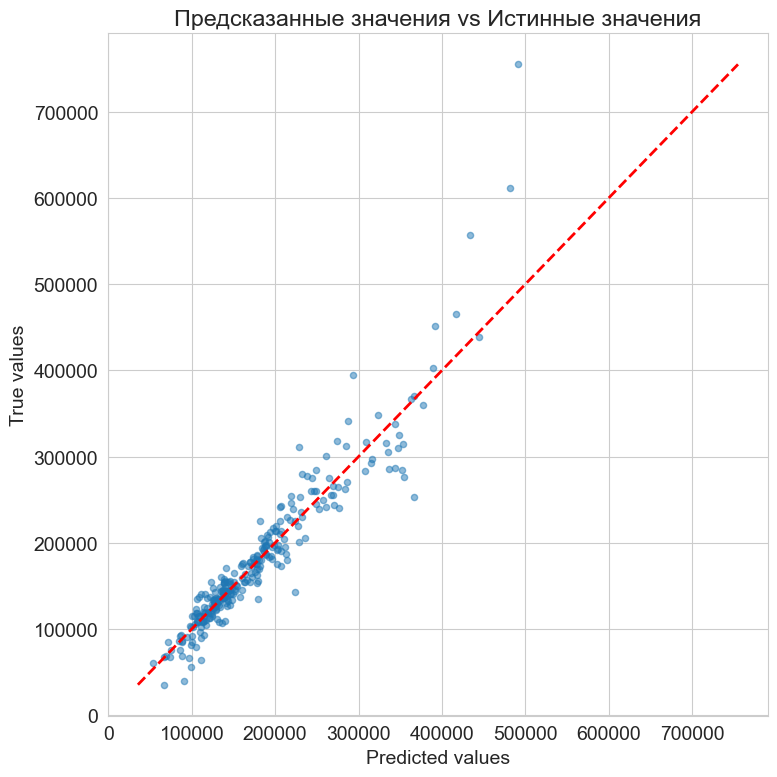

In [31]:
y_valid_true = np.expm1(y_valid_log)
y_valid_pred = np.expm1(y_valid_pred_log)

evaluate_preds(y_valid_true, y_valid_pred)

## Кросс-валидация

In [32]:
cv = KFold(n_splits=5, shuffle=True, random_state=random_state)

cv_score = -cross_val_score(
    model_pipeline,
    x,
    y_log,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=None,
)

cv_score

array([0.13410972, 0.1128976 , 0.16940305, 0.12309175, 0.1157119 ])

In [33]:
print(f"Mean CV RMSE on log-target: {cv_score.mean():.5f}")
print(f"Std CV RMSE on log-target: {cv_score.std():.5f}")

Mean CV RMSE on log-target: 0.13104
Std CV RMSE on log-target: 0.02053


## Важность признаков

In [34]:
fitted_preprocessor = model_pipeline.named_steps["column_transformer"]
fitted_model = model_pipeline.named_steps["model"]

feature_names = fitted_preprocessor.get_feature_names_out()
feature_importances = pd.DataFrame(
    {
        "feature_name": feature_names,
        "importance": fitted_model.feature_importances_,
    }
).sort_values("importance", ascending=False)

feature_importances.head(20)

,feature_name,importance
38,num__total_sf,0.371357
2,num__OverallQual,0.289329
47,num__overall_score,0.055483
41,num__total_bath,0.039828
24,num__GarageCars,0.020862
1,num__LotArea,0.016534
35,num__house_age,0.016439
39,num__total_living_area,0.015830
36,num__remod_age,0.012508
4,num__YearBuilt,0.012486


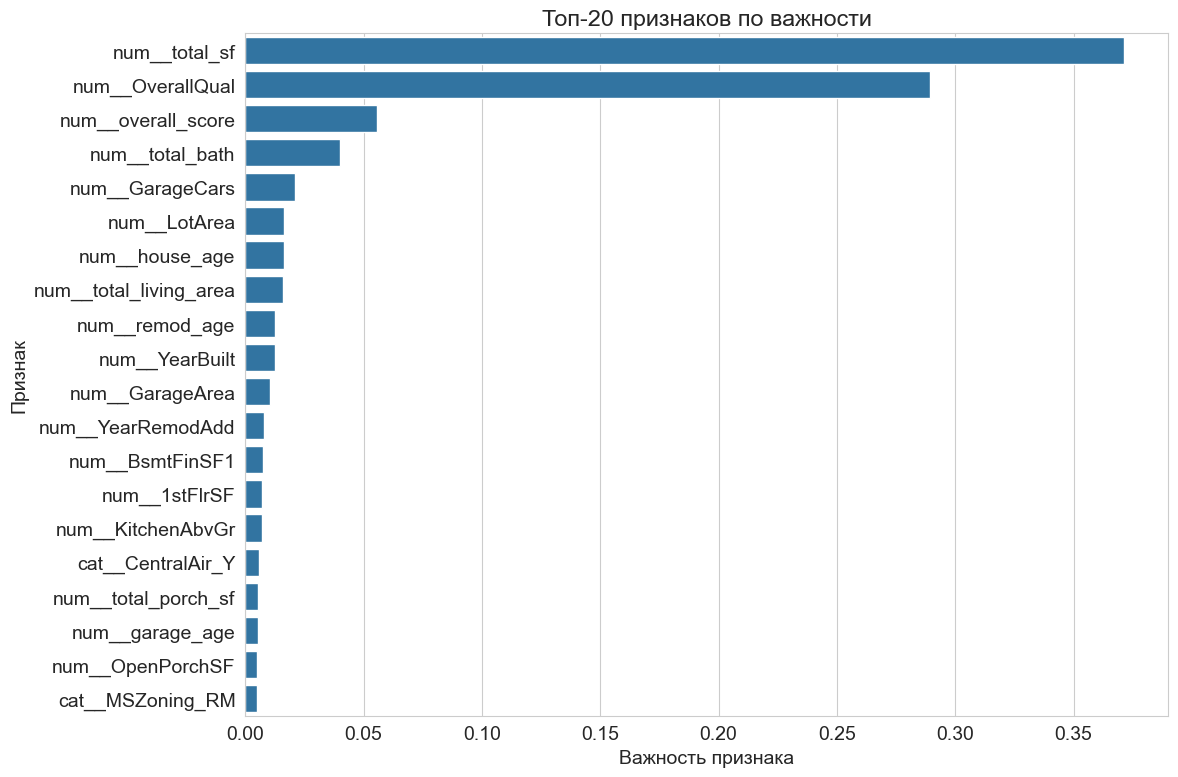

In [35]:
plt.figure(figsize=(12, 8))
sns.barplot(
    data=feature_importances.head(20),
    y="feature_name",
    x="importance",
)
plt.title("Топ-20 признаков по важности")
plt.xlabel("Важность признака")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()

# 8. Обучение модели на полном train

In [36]:
model_pipeline.fit(x, y_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('data_preprocessing', ...), ('feature_generator', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the di

# 9. Прогнозирование на тестовом датасете

In [37]:
test_pred_log = model_pipeline.predict(df_test)
test_pred = np.expm1(test_pred_log)

submission = sample_submission.copy()
submission["SalePrice"] = test_pred

submission.head()

,Id,SalePrice
0,1461,125378.525623
1,1462,164452.282648
2,1463,176753.509419
3,1464,196651.503408
4,1465,185621.077291


In [38]:
submission.to_csv("house_prices_gbr_submission.csv", index=False)
print("Файл house_prices_gbr_submission.csv сохранён.")

Файл house_prices_gbr_submission.csv сохранён.
